# NB2: 经典技术指标策略

## 研究假设
> 经典技术指标（均线交叉、RSI、布林带）是量化交易最基础的信号来源。本Notebook用它们构建三个基线策略，为后续更复杂的策略提供对比基准。

## 决策日志
| 决策 | 选择 | 为什么 |
|------|------|--------|
| 策略数量 | 3个 | 趋势跟踪（均线）、动量反转（RSI）、波动率（布林带）各一个，覆盖三种经典逻辑 |
| 参数选择 | 常用默认值 | 先用业界通用参数建立baseline，后续再做参数敏感性分析 |
| 仓位管理 | 全仓进出 | 简化模型，先验证信号本身的有效性 |
| 交易成本 | 0.1%手续费 | 接近Binance现货taker费率 |

---
## 1. 加载数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings

warnings.filterwarnings('ignore')

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")
print(f"时间范围: {df.index[0]} -> {df.index[-1]}")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

已加载: 35,064 条 BTC/USDT 1h K线
时间范围: 2021-01-01 00:00:00 -> 2024-12-31 23:00:00


---
## 2. 策略一：双均线交叉

逻辑：短期均线上穿长期均线时买入，下穿时卖出。参数用经典的20小时/60小时。

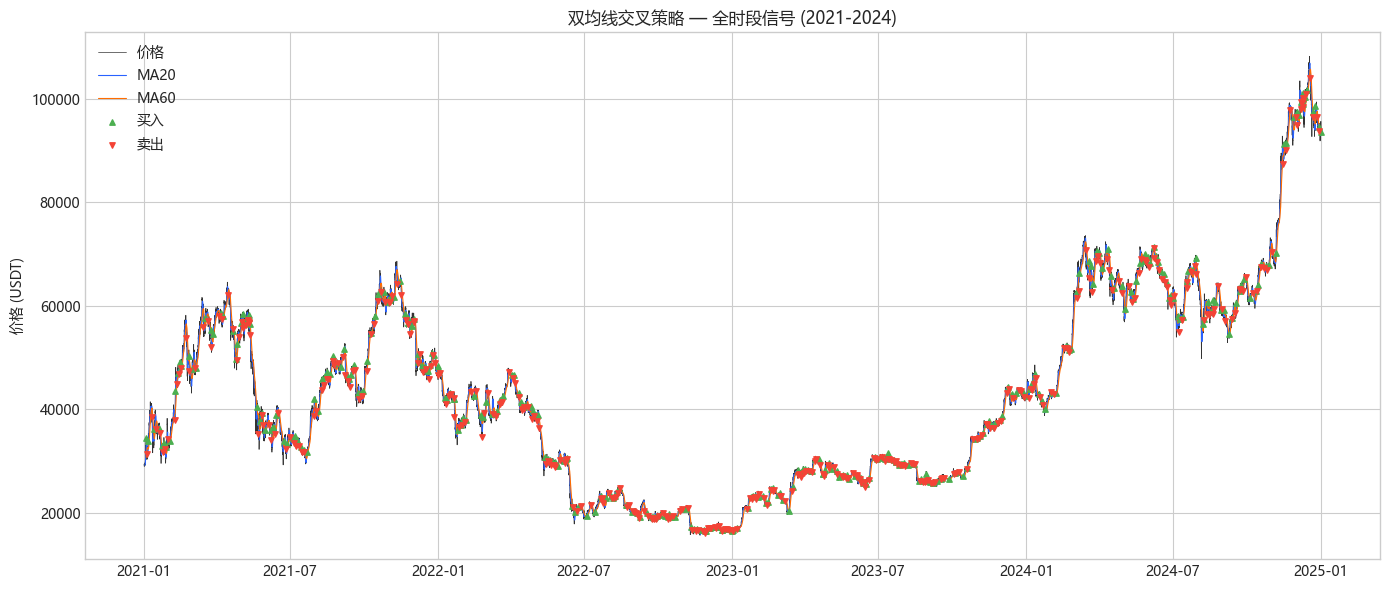

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_ma.index, df_ma['close'], linewidth=0.5, color='#333', label='价格')
ax.plot(df_ma.index, df_ma['ma_short'], linewidth=0.8, color='#2962FF', label='MA20')
ax.plot(df_ma.index, df_ma['ma_long'], linewidth=0.8, color='#FF6D00', label='MA60')

buy_points = df_ma[df_ma['position'] == 1]
sell_points = df_ma[df_ma['position'] == -1]
ax.scatter(buy_points.index, buy_points['close'], marker='^', color='#4CAF50', s=15, zorder=5, label='买入')
ax.scatter(sell_points.index, sell_points['close'], marker='v', color='#F44336', s=15, zorder=5, label='卖出')

ax.set_title('双均线交叉策略 — 全时段信号 (2021-2024)')
ax.set_ylabel('价格 (USDT)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. 策略二：RSI超买超卖

逻辑：RSI低于30时超卖买入，高于70时超买卖出。参数用经典的14周期。

In [6]:
def rsi_strategy(df, period=14, oversold=30, overbought=70):
    """RSI超买超卖策略"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    # 信号
    data['signal'] = 0
    data.loc[data['rsi'] < oversold, 'signal'] = 1
    data.loc[data['rsi'] > overbought, 'signal'] = -1
    
    # 持仓：前向填充保持状态
    data['signal'] = data['signal'].replace(0, np.nan).ffill().fillna(0)
    data['position'] = data['signal'].diff()
    
    return data

df_rsi = rsi_strategy(df)

buys = (df_rsi['position'] == 2).sum()
sells = (df_rsi['position'] == -2).sum()
print(f"RSI策略 (RSI14, 超卖30/超买70)")
print(f"买入信号: {buys} 次")
print(f"卖出信号: {sells} 次")

RSI策略 (RSI14, 超卖30/超买70)
买入信号: 388 次
卖出信号: 388 次


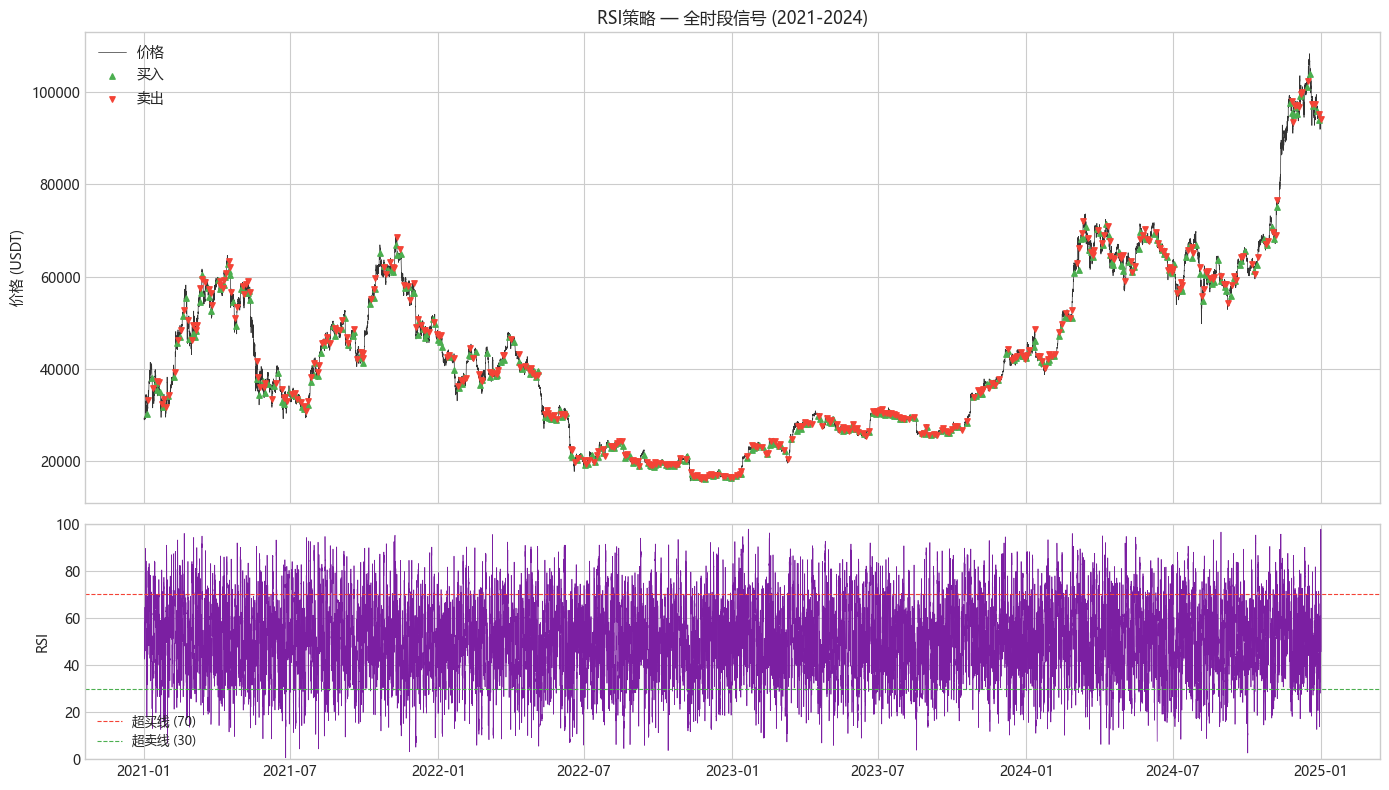

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df_rsi.index, df_rsi['close'], linewidth=0.5, color='#333', label='价格')
buy_points = df_rsi[df_rsi['position'] == 2]
sell_points = df_rsi[df_rsi['position'] == -2]
axes[0].scatter(buy_points.index, buy_points['close'], marker='^', color='#4CAF50', s=15, zorder=5, label='买入')
axes[0].scatter(sell_points.index, sell_points['close'], marker='v', color='#F44336', s=15, zorder=5, label='卖出')
axes[0].set_ylabel('价格 (USDT)')
axes[0].set_title('RSI策略 — 全时段信号 (2021-2024)')
axes[0].legend()

axes[1].plot(df_rsi.index, df_rsi['rsi'], linewidth=0.5, color='#7B1FA2')
axes[1].axhline(70, color='#F44336', linestyle='--', linewidth=0.8, label='超买线 (70)')
axes[1].axhline(30, color='#4CAF50', linestyle='--', linewidth=0.8, label='超卖线 (30)')
axes[1].fill_between(df_rsi.index, 30, 70, alpha=0.05, color='gray')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. 策略三：布林带突破

逻辑：价格跌破下轨时买入（超跌反弹），突破上轨时卖出（获利了结）。参数用经典的20周期、2倍标准差。

In [8]:
def bollinger_strategy(df, window=20, num_std=2):
    """布林带突破策略"""
    data = df.copy()
    
    data['bb_mid'] = data['close'].rolling(window).mean()
    data['bb_std'] = data['close'].rolling(window).std()
    data['bb_upper'] = data['bb_mid'] + num_std * data['bb_std']
    data['bb_lower'] = data['bb_mid'] - num_std * data['bb_std']
    
    # 信号
    data['signal'] = 0
    data.loc[data['close'] < data['bb_lower'], 'signal'] = 1
    data.loc[data['close'] > data['bb_upper'], 'signal'] = -1
    
    # 持仓：前向填充保持状态
    data['signal'] = data['signal'].replace(0, np.nan).ffill().fillna(0)
    data['position'] = data['signal'].diff()
    
    return data

df_bb = bollinger_strategy(df)

buys = (df_bb['position'] == 2).sum()
sells = (df_bb['position'] == -2).sum()
print(f"布林带策略 (BB20, 2倍标准差)")
print(f"买入信号: {buys} 次")
print(f"卖出信号: {sells} 次")

布林带策略 (BB20, 2倍标准差)
买入信号: 418 次
卖出信号: 418 次


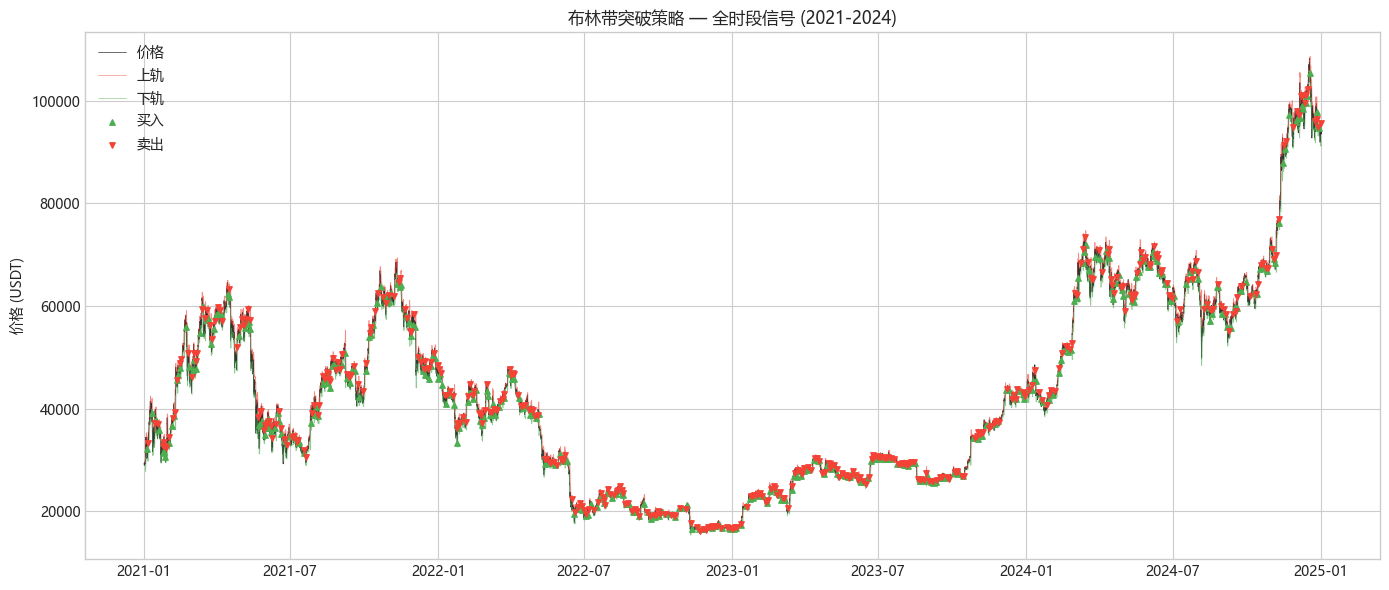

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_bb.index, df_bb['close'], linewidth=0.5, color='#333', label='价格')
ax.plot(df_bb.index, df_bb['bb_upper'], linewidth=0.5, color='#F44336', alpha=0.6, label='上轨')
ax.plot(df_bb.index, df_bb['bb_lower'], linewidth=0.5, color='#4CAF50', alpha=0.6, label='下轨')
ax.fill_between(df_bb.index, df_bb['bb_upper'], df_bb['bb_lower'], alpha=0.05, color='gray')

buy_points = df_bb[df_bb['position'] == 2]
sell_points = df_bb[df_bb['position'] == -2]
ax.scatter(buy_points.index, buy_points['close'], marker='^', color='#4CAF50', s=15, zorder=5, label='买入')
ax.scatter(sell_points.index, sell_points['close'], marker='v', color='#F44336', s=15, zorder=5, label='卖出')

ax.set_title('布林带突破策略 — 全时段信号 (2021-2024)')
ax.set_ylabel('价格 (USDT)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. 简易回测

统一回测框架：计算每个策略的收益曲线，考虑0.1%交易手续费。

In [10]:
def simple_backtest(df, signal_col='signal', fee=0.001):
    """
    简易回测
    - signal: 1=持仓, -1=空仓(或反向), 0=空仓
    - fee: 单次交易手续费
    """
    data = df.copy()
    
    # 将信号统一为 1(持仓) 和 0(空仓)
    data['hold'] = data[signal_col].clip(lower=0)
    
    # 策略收益 = 持仓 * 市场收益
    data['strategy_returns'] = data['hold'].shift(1) * data['returns']
    
    # 扣除手续费：每次仓位变化时扣费
    trades = data['hold'].diff().abs()
    data['strategy_returns'] -= trades * fee
    
    # 累计收益曲线
    data['cumulative_market'] = (1 + data['returns']).cumprod()
    data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()
    
    return data

print("回测函数定义完成")

回测函数定义完成


In [11]:
df_ma_bt = simple_backtest(df_ma)
df_rsi_bt = simple_backtest(df_rsi)
df_bb_bt = simple_backtest(df_bb)

print("三个策略回测完成")

三个策略回测完成


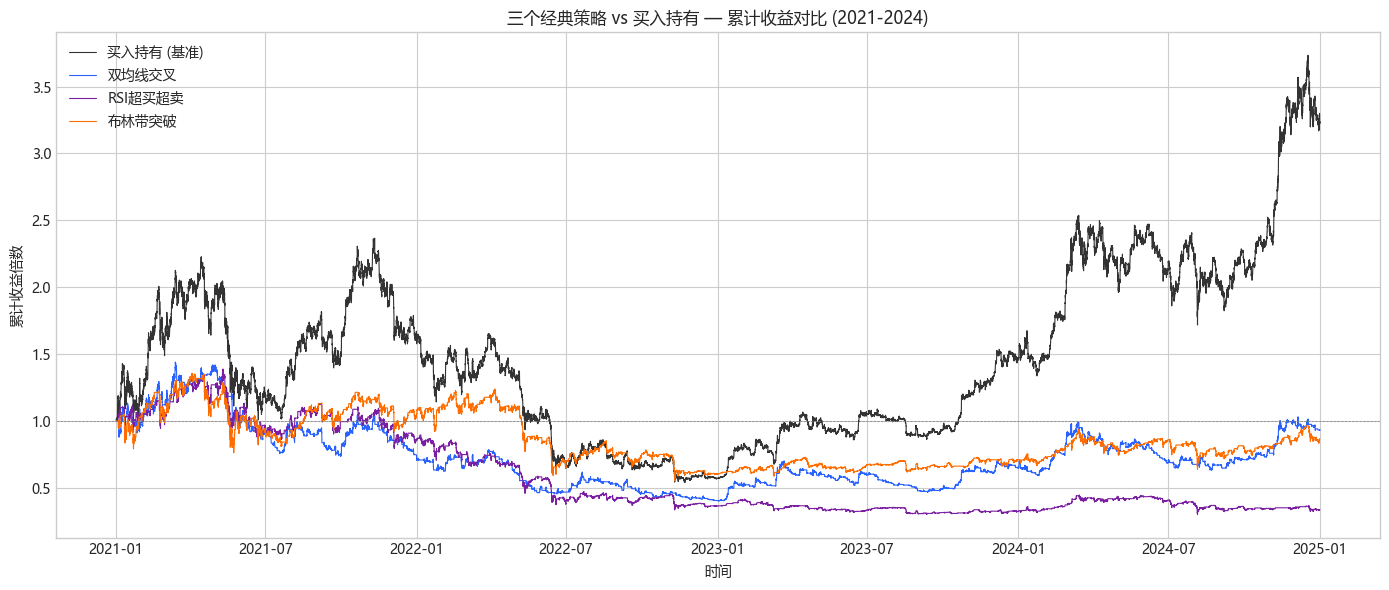

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_ma_bt.index, df_ma_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有 (基准)')
ax.plot(df_ma_bt.index, df_ma_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='双均线交叉')
ax.plot(df_rsi_bt.index, df_rsi_bt['cumulative_strategy'], linewidth=0.8, color='#7B1FA2', label='RSI超买超卖')
ax.plot(df_bb_bt.index, df_bb_bt['cumulative_strategy'], linewidth=0.8, color='#FF6D00', label='布林带突破')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('三个经典策略 vs 买入持有 — 累计收益对比 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. 绩效指标对比

In [13]:
def calc_metrics(data, strategy_name):
    """计算核心绩效指标"""
    ret = data['strategy_returns'].dropna()
    cum = data['cumulative_strategy'].dropna()
    
    total_return = cum.iloc[-1] / cum.iloc[0] - 1
    annual_return = (1 + total_return) ** (8760 / len(ret)) - 1
    annual_vol = ret.std() * np.sqrt(8760)
    sharpe = annual_return / annual_vol if annual_vol != 0 else 0
    
    # 最大回撤
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_drawdown = drawdown.min()
    
    # 胜率
    trades = ret[ret != 0]
    win_rate = (trades > 0).sum() / len(trades) if len(trades) > 0 else 0
    
    return {
        '策略': strategy_name,
        '总收益': f"{total_return:.1%}",
        '年化收益': f"{annual_return:.1%}",
        '年化波动': f"{annual_vol:.1%}",
        '夏普比率': f"{sharpe:.2f}",
        '最大回撤': f"{max_drawdown:.1%}",
        '胜率': f"{win_rate:.1%}",
    }

# 买入持有基准
df_hold = df.copy()
df_hold['strategy_returns'] = df_hold['returns']
df_hold['cumulative_strategy'] = (1 + df_hold['returns']).cumprod()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_ma_bt, '双均线交叉'),
    calc_metrics(df_rsi_bt, 'RSI超买超卖'),
    calc_metrics(df_bb_bt, '布林带突破'),
]

pd.DataFrame(results).set_index('策略')

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
双均线交叉,-6.9%,-1.8%,42.0%,-0.04,-72.1%,49.0%
RSI超买超卖,-66.2%,-23.7%,45.6%,-0.52,-78.4%,49.9%
布林带突破,-13.3%,-3.5%,47.9%,-0.07,-59.3%,50.8%


In [17]:
def rsi_position_sizing(df, period=168):
    """RSI(7日)分仓策略"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    # 只在极端区域触发信号，中间区域保持不变
    data['signal'] = np.nan
    data.loc[data['rsi'] <= 30, 'signal'] = 1.0    # 超卖全仓
    data.loc[data['rsi'] >= 70, 'signal'] = 0.0    # 超买清仓
    
    # 中间区域前向填充，保持上一次的仓位
    data['signal'] = data['signal'].ffill().fillna(0)
    
    return data

df_rsi_sized = rsi_position_sizing(df)
print("RSI(7日)分仓 — 仓位分布:")
print(df_rsi_sized['signal'].value_counts().sort_index())

RSI(7日)分仓 — 仓位分布:
signal
0.0    23013
1.0    12051
Name: count, dtype: int64


---
## 7. 改进：RSI加仓 + 均线止盈

思路：RSI<=30时买入，但不用RSI清仓。改用价格跌破60日均线时止盈离场。这样不会在上涨趋势中过早清仓。

In [18]:
print(f"RSI 统计:")
print(f"  最小值: {df_rsi_sized['rsi'].min():.1f}")
print(f"  最大值: {df_rsi_sized['rsi'].max():.1f}")
print(f"  均值: {df_rsi_sized['rsi'].mean():.1f}")
print(f"  低于30的次数: {(df_rsi_sized['rsi'] < 30).sum()}")
print(f"  低于40的次数: {(df_rsi_sized['rsi'] < 40).sum()}")
print(f"  高于60的次数: {(df_rsi_sized['rsi'] > 60).sum()}")
print(f"  高于75的次数: {(df_rsi_sized['rsi'] > 75).sum()}")

RSI 统计:
  最小值: 28.5
  最大值: 73.6
  均值: 50.6
  低于30的次数: 1
  低于40的次数: 906
  高于60的次数: 1876
  高于75的次数: 0


In [19]:
def rsi_position_sizing(df, period=14):
    """RSI(14)分仓策略"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    data['signal'] = np.nan
    data.loc[data['rsi'] <= 30, 'signal'] = 1.0
    data.loc[data['rsi'] >= 70, 'signal'] = 0.0
    
    data['signal'] = data['signal'].ffill().fillna(0)
    
    return data

df_rsi_sized = rsi_position_sizing(df)
print("RSI(14)分仓 — 仓位分布:")
print(df_rsi_sized['signal'].value_counts().sort_index())

RSI(14)分仓 — 仓位分布:
signal
0.0    18549
1.0    16515
Name: count, dtype: int64


回测函数定义完成


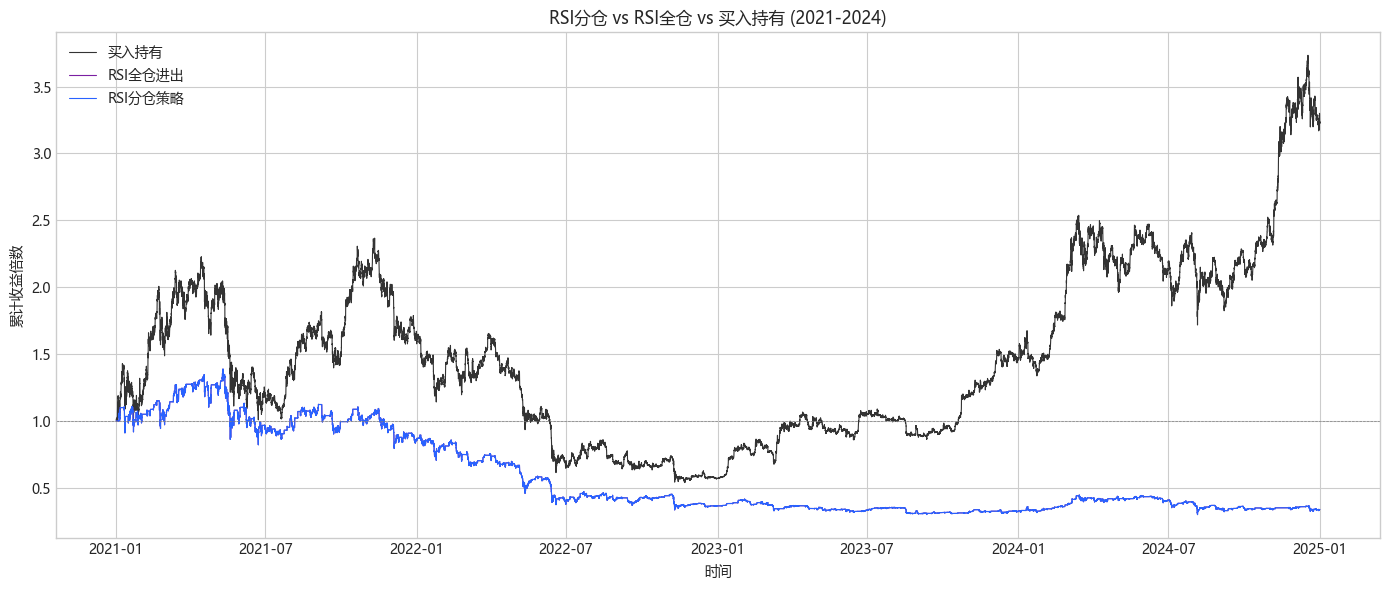

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
RSI全仓进出,-66.2%,-23.7%,45.6%,-0.52,-78.4%,49.9%
RSI分仓策略,-66.2%,-23.7%,45.6%,-0.52,-78.4%,49.9%


In [21]:
def backtest_sized(df, fee=0.001):
    """支持分仓的回测"""
    data = df.copy()
    
    data['strategy_returns'] = data['signal'].shift(1) * data['returns']
    
    position_change = data['signal'].diff().abs()
    data['strategy_returns'] -= position_change * fee
    
    data['cumulative_market'] = (1 + data['returns']).cumprod()
    data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()
    
    return data

print("回测函数定义完成")


df_rsi_sized_bt = backtest_sized(df_rsi_sized)

# 和之前的全仓RSI、买入持有对比
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_rsi_sized_bt.index, df_rsi_sized_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_rsi_bt.index, df_rsi_bt['cumulative_strategy'], linewidth=0.8, color='#7B1FA2', label='RSI全仓进出')
ax.plot(df_rsi_sized_bt.index, df_rsi_sized_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='RSI分仓策略')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('RSI分仓 vs RSI全仓 vs 买入持有 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

# 绩效对比
results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_rsi_bt, 'RSI全仓进出'),
    calc_metrics(df_rsi_sized_bt, 'RSI分仓策略'),
]
pd.DataFrame(results).set_index('策略')

In [22]:
def rsi_ma_strategy(df, rsi_period=14, ma_period=60):
    """RSI加仓 + 均线止盈"""
    data = df.copy()
    
    # 计算RSI
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    # 计算均线
    data['ma'] = data['close'].rolling(ma_period).mean()
    
    # 信号逻辑
    data['signal'] = np.nan
    data.loc[data['rsi'] <= 30, 'signal'] = 1.0           # RSI超卖 -> 买入
    data.loc[data['close'] < data['ma'], 'signal'] = 0.0   # 跌破均线 -> 清仓
    
    # 中间状态保持上一次仓位
    data['signal'] = data['signal'].ffill().fillna(0)
    
    return data

df_rsi_ma = rsi_ma_strategy(df)
print("RSI加仓+均线止盈 — 仓位分布:")
print(df_rsi_ma['signal'].value_counts().sort_index())

RSI加仓+均线止盈 — 仓位分布:
signal
0.0    32733
1.0     2331
Name: count, dtype: int64


In [23]:
def rsi_ma_strategy_v2(df, rsi_period=14, ma_period=60):
    """RSI加仓 + 均线止盈 v2"""
    data = df.copy()
    
    # 计算RSI
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    # 计算均线
    data['ma'] = data['close'].rolling(ma_period).mean()
    
    # 逐行遍历，维护持仓状态
    signals = np.zeros(len(data))
    holding = False
    above_ma_since_entry = False
    
    for i in range(1, len(data)):
        rsi = data['rsi'].iloc[i]
        close = data['close'].iloc[i]
        ma = data['ma'].iloc[i]
        
        if not holding and rsi <= 30:
            holding = True
            above_ma_since_entry = False
        
        if holding:
            if close > ma:
                above_ma_since_entry = True
            
            # 只有价格曾经回到均线上方后，再跌破才止盈
            if above_ma_since_entry and close < ma:
                holding = False
        
        signals[i] = 1.0 if holding else 0.0
    
    data['signal'] = signals
    return data

df_rsi_ma = rsi_ma_strategy_v2(df)
print("RSI加仓+均线止盈 v2 — 仓位分布:")
print(df_rsi_ma['signal'].value_counts().sort_index())

RSI加仓+均线止盈 v2 — 仓位分布:
signal
0.0    14769
1.0    20295
Name: count, dtype: int64


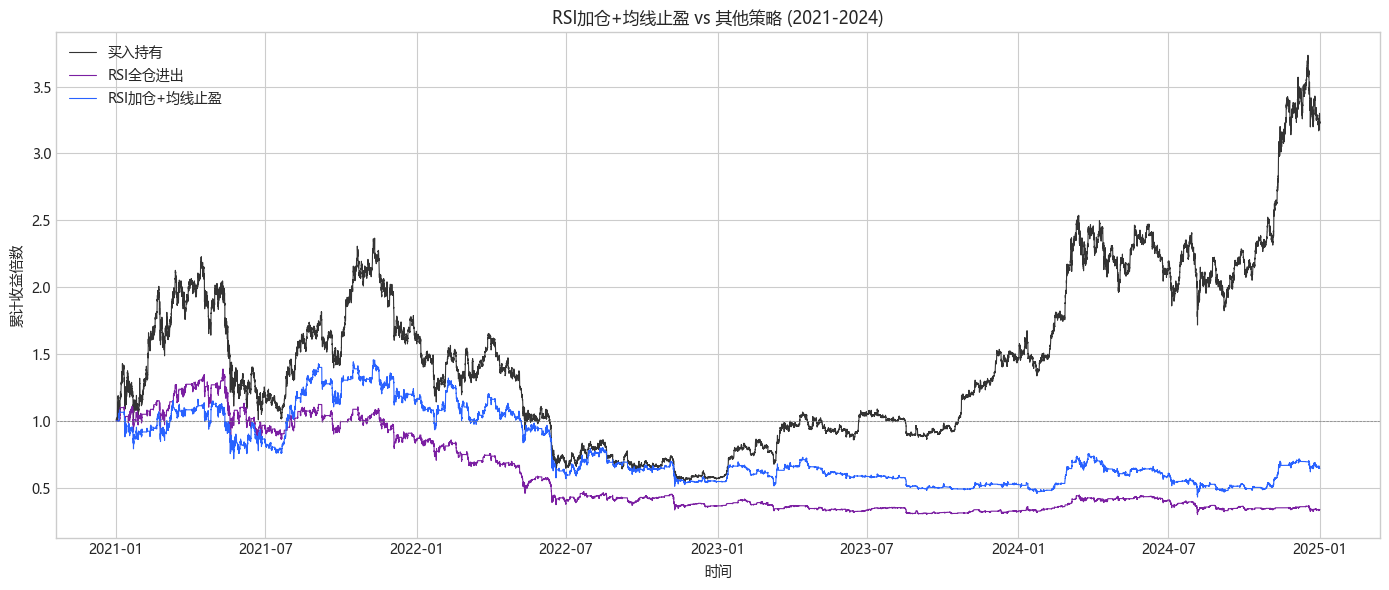

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
RSI全仓进出,-66.2%,-23.7%,45.6%,-0.52,-78.4%,49.9%
RSI加仓+均线止盈,-35.4%,-10.3%,51.3%,-0.20,-70.4%,49.8%


In [24]:
df_rsi_ma_bt = backtest_sized(df_rsi_ma)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_rsi_ma_bt.index, df_rsi_ma_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_rsi_bt.index, df_rsi_bt['cumulative_strategy'], linewidth=0.8, color='#7B1FA2', label='RSI全仓进出')
ax.plot(df_rsi_ma_bt.index, df_rsi_ma_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='RSI加仓+均线止盈')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('RSI加仓+均线止盈 vs 其他策略 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_rsi_bt, 'RSI全仓进出'),
    calc_metrics(df_rsi_ma_bt, 'RSI加仓+均线止盈'),
]
pd.DataFrame(results).set_index('策略')

In [26]:
for year in ['2021', '2022', '2023', '2024']:
    yearly = df_rsi_ma_bt.loc[year]
    if len(yearly) > 0:
        ret = yearly['cumulative_strategy'].iloc[-1] / yearly['cumulative_strategy'].iloc[0] - 1
        hold = yearly['cumulative_market'].iloc[-1] / yearly['cumulative_market'].iloc[0] - 1
        hold_pct = (yearly['signal'] == 1).mean()
        print(f"{year}: 策略 {ret:+.1%}  买入持有 {hold:+.1%}  持仓占比 {hold_pct:.0%}")

2021: 策略 +nan%  买入持有 +nan%  持仓占比 62%
2022: 策略 -52.6%  买入持有 -64.5%  持仓占比 64%
2023: 策略 -4.1%  买入持有 +155.8%  持仓占比 50%
2024: 策略 +22.6%  买入持有 +120.3%  持仓占比 56%


In [29]:
def rsi_ma_strategy_v3(df, rsi_period=14, ma_period=60):
    """v3: RSI加仓 + 均线止盈 + 趋势跟随"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    data['ma'] = data['close'].rolling(ma_period).mean()
    
    signals = np.zeros(len(data))
    holding = False
    above_ma_since_entry = False
    
    for i in range(1, len(data)):
        rsi = data['rsi'].iloc[i]
        close = data['close'].iloc[i]
        ma = data['ma'].iloc[i]
        
        if np.isnan(rsi) or np.isnan(ma):
            signals[i] = 1.0 if holding else 0.0
            continue
        
        # 入场条件：RSI<=30 或 价格站上均线（趋势跟随）
        if not holding:
            if rsi <= 30 or close > ma:
                holding = True
                above_ma_since_entry = close > ma
        
        # 出场条件：价格曾在均线上方，再跌破均线
        if holding:
            if close > ma:
                above_ma_since_entry = True
            if above_ma_since_entry and close < ma:
                holding = False
                above_ma_since_entry = False
        
        signals[i] = 1.0 if holding else 0.0
    
    data['signal'] = signals
    return data

df_rsi_ma_v3 = rsi_ma_strategy_v3(df)
df_rsi_ma_v3_bt = backtest_sized(df_rsi_ma_v3)

for year in ['2021', '2022', '2023', '2024']:
    yearly = df_rsi_ma_v3_bt.loc[year]
    if len(yearly) > 0:
        ret = yearly['cumulative_strategy'].iloc[-1] / yearly['cumulative_strategy'].iloc[0] - 1
        hold = yearly['cumulative_market'].iloc[-1] / yearly['cumulative_market'].iloc[0] - 1
        hold_pct = (yearly['signal'] == 1).mean()
        print(f"{year}: 策略 {ret:+.1%}  买入持有 {hold:+.1%}  持仓占比 {hold_pct:.0%}")

2021: 策略 +nan%  买入持有 +nan%  持仓占比 88%
2022: 策略 -82.1%  买入持有 -64.5%  持仓占比 85%
2023: 策略 -5.6%  买入持有 +155.8%  持仓占比 84%
2024: 策略 +21.3%  买入持有 +120.3%  持仓占比 87%


In [30]:
def rsi_ma_strategy_v4(df, rsi_period=14, ma_period=60, stop_loss=0.08):
    """v4: RSI加仓 + 均线止盈 + 8%止损"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    data['ma'] = data['close'].rolling(ma_period).mean()
    
    signals = np.zeros(len(data))
    holding = False
    above_ma_since_entry = False
    entry_price = 0
    
    for i in range(1, len(data)):
        rsi = data['rsi'].iloc[i]
        close = data['close'].iloc[i]
        ma = data['ma'].iloc[i]
        
        if np.isnan(rsi) or np.isnan(ma):
            signals[i] = 1.0 if holding else 0.0
            continue
        
        # 入场：RSI<=30
        if not holding and rsi <= 30:
            holding = True
            above_ma_since_entry = False
            entry_price = close
        
        if holding:
            if close > ma:
                above_ma_since_entry = True
            
            # 止盈：曾在均线上方后跌破
            if above_ma_since_entry and close < ma:
                holding = False
            
            # 止损：跌破入场价8%
            if close < entry_price * (1 - stop_loss):
                holding = False
        
        signals[i] = 1.0 if holding else 0.0
    
    data['signal'] = signals
    return data

df_v4 = rsi_ma_strategy_v4(df)
df_v4_bt = backtest_sized(df_v4)

for year in ['2021', '2022', '2023', '2024']:
    yearly = df_v4_bt.loc[year]
    if len(yearly) > 0:
        ret = yearly['cumulative_strategy'].iloc[-1] / yearly['cumulative_strategy'].iloc[0] - 1
        hold = yearly['cumulative_market'].iloc[-1] / yearly['cumulative_market'].iloc[0] - 1
        hold_pct = (yearly['signal'] == 1).mean()
        print(f"{year}: 策略 {ret:+.1%}  买入持有 {hold:+.1%}  持仓占比 {hold_pct:.0%}")

2021: 策略 +nan%  买入持有 +nan%  持仓占比 60%
2022: 策略 -55.2%  买入持有 -64.5%  持仓占比 63%
2023: 策略 -6.9%  买入持有 +155.8%  持仓占比 50%
2024: 策略 +13.3%  买入持有 +120.3%  持仓占比 55%


In [31]:
def rsi_ma_strategy_v5(df, rsi_period=14, ma_period=60, trailing_pct=0.15):
    """v5: RSI加仓 + 均线止盈 + 15%移动止损"""
    data = df.copy()
    
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(rsi_period).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    data['ma'] = data['close'].rolling(ma_period).mean()
    
    signals = np.zeros(len(data))
    holding = False
    above_ma_since_entry = False
    peak_price = 0
    
    for i in range(1, len(data)):
        rsi = data['rsi'].iloc[i]
        close = data['close'].iloc[i]
        ma = data['ma'].iloc[i]
        
        if np.isnan(rsi) or np.isnan(ma):
            signals[i] = 1.0 if holding else 0.0
            continue
        
        # 入场
        if not holding and rsi <= 30:
            holding = True
            above_ma_since_entry = False
            peak_price = close
        
        if holding:
            # 更新持仓期间最高价
            if close > peak_price:
                peak_price = close
            
            if close > ma:
                above_ma_since_entry = True
            
            # 止盈：曾在均线上方后跌破
            if above_ma_since_entry and close < ma:
                holding = False
            
            # 移动止损：从最高价回撤15%
            if close < peak_price * (1 - trailing_pct):
                holding = False
        
        signals[i] = 1.0 if holding else 0.0
    
    data['signal'] = signals
    return data

df_v5 = rsi_ma_strategy_v5(df)
df_v5_bt = backtest_sized(df_v5)

for year in ['2021', '2022', '2023', '2024']:
    yearly = df_v5_bt.loc[year]
    if len(yearly) > 0:
        ret = yearly['cumulative_strategy'].iloc[-1] / yearly['cumulative_strategy'].iloc[0] - 1
        hold = yearly['cumulative_market'].iloc[-1] / yearly['cumulative_market'].iloc[0] - 1
        hold_pct = (yearly['signal'] == 1).mean()
        print(f"{year}: 策略 {ret:+.1%}  买入持有 {hold:+.1%}  持仓占比 {hold_pct:.0%}")

2021: 策略 +nan%  买入持有 +nan%  持仓占比 61%
2022: 策略 -58.7%  买入持有 -64.5%  持仓占比 63%
2023: 策略 -4.1%  买入持有 +155.8%  持仓占比 50%
2024: 策略 +19.8%  买入持有 +120.3%  持仓占比 56%


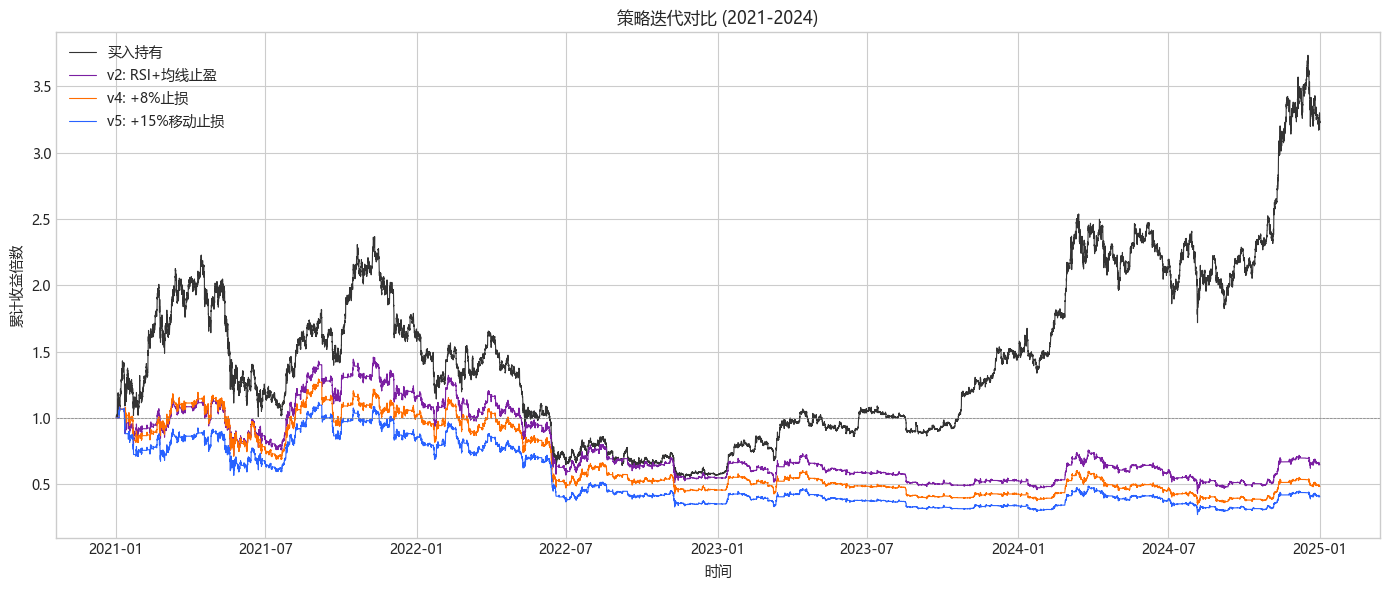

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
v2: RSI+均线止盈,-35.4%,-10.3%,51.3%,-0.20,-70.4%,49.8%
v4: +8%止损,-51.7%,-16.6%,50.2%,-0.33,-73.3%,49.6%
v5: +15%移动止损,-59.5%,-20.2%,50.3%,-0.40,-75.8%,49.7%


In [32]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_rsi_ma_bt.index, df_rsi_ma_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_rsi_ma_bt.index, df_rsi_ma_bt['cumulative_strategy'], linewidth=0.8, color='#7B1FA2', label='v2: RSI+均线止盈')
ax.plot(df_v4_bt.index, df_v4_bt['cumulative_strategy'], linewidth=0.8, color='#FF6D00', label='v4: +8%止损')
ax.plot(df_v5_bt.index, df_v5_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='v5: +15%移动止损')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('策略迭代对比 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_rsi_ma_bt, 'v2: RSI+均线止盈'),
    calc_metrics(df_v4_bt, 'v4: +8%止损'),
    calc_metrics(df_v5_bt, 'v5: +15%移动止损'),
]
pd.DataFrame(results).set_index('策略')

---
## 小结

**策略表现**
- 三个经典策略（均线交叉、RSI、布林带）均未跑赢买入持有
- 买入持有总收益+218%，最好的策略（均线交叉）也亏了-6.9%

**迭代过程**
1. 基线策略：RSI全仓进出，总收益-66%，在超买区过早清仓错过大段涨幅
2. RSI+均线止盈：改用跌破均线离场，改善到-35%，但2023年反弹没能重新入场
3. 加入固定止损/移动止损：反而更差（-51%/-59%），BTC高波动频繁触发止损，每次出场再入场都多亏一轮

**关键发现**
1. 在长期上涨+高波动的市场中，择时策略很难跑赢持有，频繁进出的成本远超收益
2. 止损机制在高波动资产上可能适得其反，正常回调就被止损踢出，错过后续反弹
3. 经典技术指标的默认参数不能直接套用到加密货币市场，波动率特征差异太大

**对后续的启示**
- 单一指标信号太弱，NB3尝试统计方法做多因子组合
- 与其择时进出，不如研究仓位动态调整（降低择时频率）